In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import pyarrow.parquet as pq

pf = pq.ParquetFile("/kaggle/input/datasets/anujgautampanipat/delhi-aqi/team_7.parquet")

print("Total rows:", pf.metadata.num_rows)

Total rows: 10397242


In [6]:
import pyarrow.parquet as pq
import pandas as pd
import os
import zipfile
from google.colab import files

OUTPUT_DIR  = "./monthly_csvs_split"
ZIP_PATH    = "./air_quality_csvs.zip"
FILE_PATH   = "/kaggle/input/datasets/anujgautampanipat/delhi-aqi/team_7.parquet"
CHUNK_ROWS  = 50_000

os.makedirs(OUTPUT_DIR, exist_ok=True)

pf = pq.ParquetFile(FILE_PATH)
print(f"Total rows: {pf.metadata.num_rows:,}")

# Step 1 — read row-group by row-group and bucket by month
monthly_buffers = {}
for i in range(pf.num_row_groups):
    print(f"  Reading row group {i+1}/{pf.num_row_groups}...", end=" ", flush=True)
    df = pf.read_row_group(i).to_pandas()
    for (yr, mo), grp in df.groupby(["year", "month"]):
        key = (int(yr), int(mo))
        if key not in monthly_buffers:
            monthly_buffers[key] = []
        monthly_buffers[key].append(grp)
    print(f"{len(df):,} rows")

# Step 2 — write chunked CSVs
all_files = []
for (yr, mo) in sorted(monthly_buffers.keys()):
    combined = pd.concat(monthly_buffers[(yr, mo)], ignore_index=True)
    for part, start in enumerate(range(0, len(combined), CHUNK_ROWS), start=1):
        chunk    = combined.iloc[start : start + CHUNK_ROWS]
        filename = f"data_{yr}_{mo:02d}_part{part:02d}.csv"
        out_path = os.path.join(OUTPUT_DIR, filename)
        chunk.to_csv(out_path, index=False)
        all_files.append(out_path)
        print(f"  {filename} | {len(chunk):,} rows | {os.path.getsize(out_path)//1024//1024} MB")

# Step 3 — zip everything
print(f"\nZipping {len(all_files)} files...")
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fpath in all_files:
        zf.write(fpath, arcname=os.path.basename(fpath))

print(f"✓ Done! Zip size: {os.path.getsize(ZIP_PATH)//1024//1024} MB")

# Step 4 — download the zip
files.download(ZIP_PATH)

Total rows: 10,397,242
  Reading row group 1/10... 1,048,576 rows
  Reading row group 2/10... 1,048,576 rows
  Reading row group 3/10... 1,048,576 rows
  Reading row group 4/10... 1,048,576 rows
  Reading row group 5/10... 1,048,576 rows
  Reading row group 6/10... 1,048,576 rows
  Reading row group 7/10... 1,048,576 rows
  Reading row group 8/10... 1,048,576 rows
  Reading row group 9/10... 1,048,576 rows
  Reading row group 10/10... 960,058 rows
  data_2024_01_part01.csv | 50,000 rows | 9 MB
  data_2024_01_part02.csv | 50,000 rows | 9 MB
  data_2024_01_part03.csv | 50,000 rows | 9 MB
  data_2024_01_part04.csv | 50,000 rows | 9 MB
  data_2024_01_part05.csv | 50,000 rows | 9 MB
  data_2024_01_part06.csv | 50,000 rows | 9 MB
  data_2024_01_part07.csv | 50,000 rows | 9 MB
  data_2024_01_part08.csv | 50,000 rows | 9 MB
  data_2024_01_part09.csv | 50,000 rows | 9 MB
  data_2024_01_part10.csv | 7,481 rows | 1 MB
  data_2024_02_part01.csv | 50,000 rows | 9 MB
  data_2024_02_part02.csv | 50,0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Libraries imported
Found 219 CSV files in zip
  Loaded 50/219 files...
  Loaded 100/219 files...
  Loaded 150/219 files...
  Loaded 200/219 files...
  Loaded 219/219 files...

✓ Raw data shape: 10,397,242 rows × 22 columns
  station_id  state   city               station_name  \
0   site_118  Delhi  Delhi          DTU, Delhi - CPCB   
1  site_1429  Delhi  Delhi  Nehru Nagar, Delhi - DPCC   
2  site_1427  Delhi  Delhi    Najafgarh, Delhi - DPCC   

                         timestamp                  datetime  at_c  \
0  2024-01-01T00:00:00.000000+0000 2024-01-01 00:00:00+00:00   NaN   
1  2024-01-01T00:00:00.000000+0000 2024-01-01 00:00:00+00:00   9.6   
2  2024-01-01T00:00:00.000000+0000 2024-01-01 00:00:00+00:00  13.3   

   rh_percent  ws_m_s  wd_deg  ...  sr_w_mt2  bp_mmhg  vws_m_s  pollutant  \
0       93.12    0.72   39.64  ...       NaN      NaN      NaN    benzene   
1       75.40    0.30  222.80  ...       4.3    986.5      NaN    benzene   
2       77.10    0.20  185.70  ...

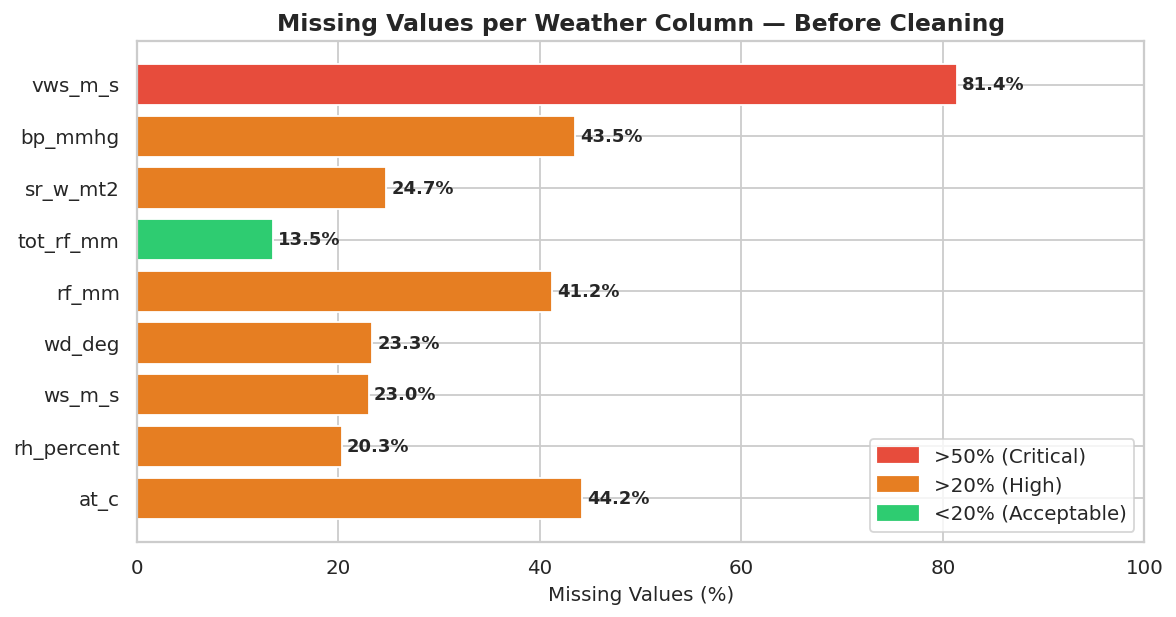

  ✓ Saved & displayed → ./output_plots/01_missing_values.png

Plot 2: PM2.5 Monthly Trend (2024–2025)


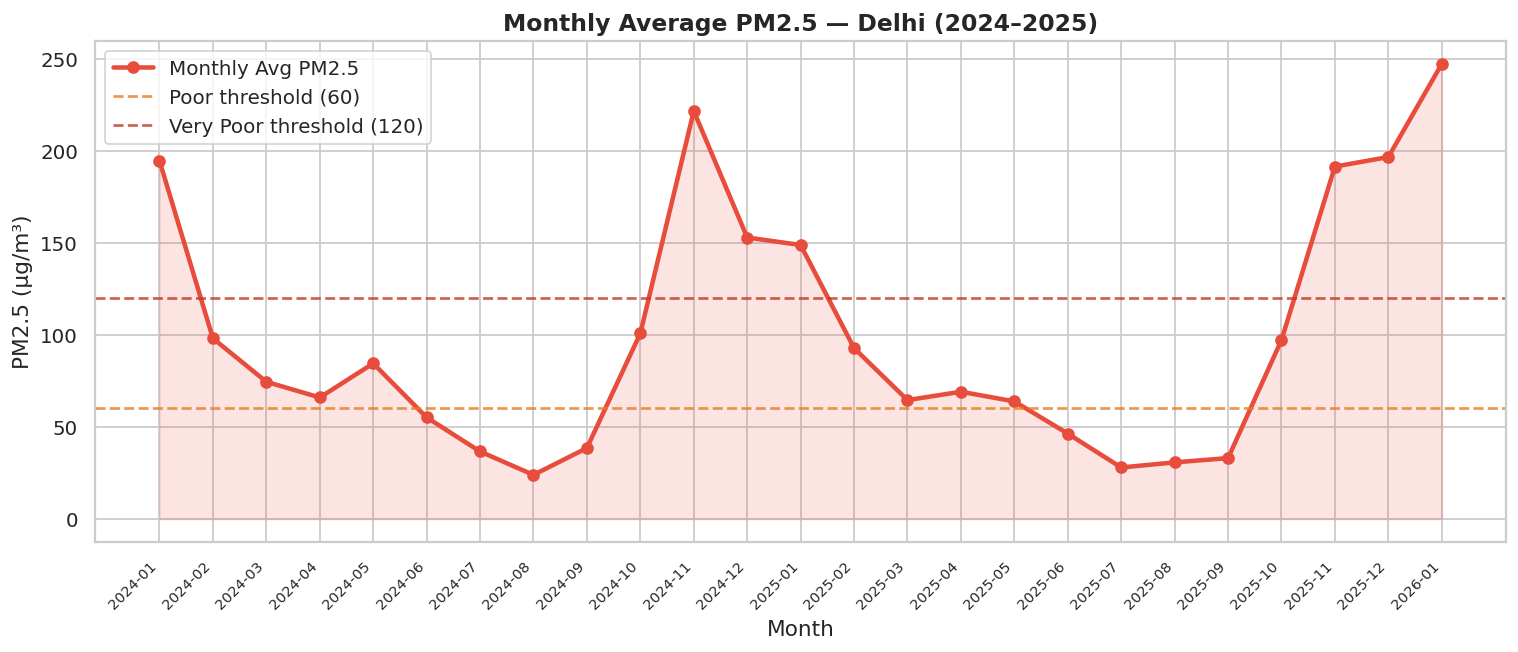

  ✓ Saved & displayed → ./output_plots/02_pm25_monthly_trend.png

Plot 3: Average PM2.5 by Monitoring Station


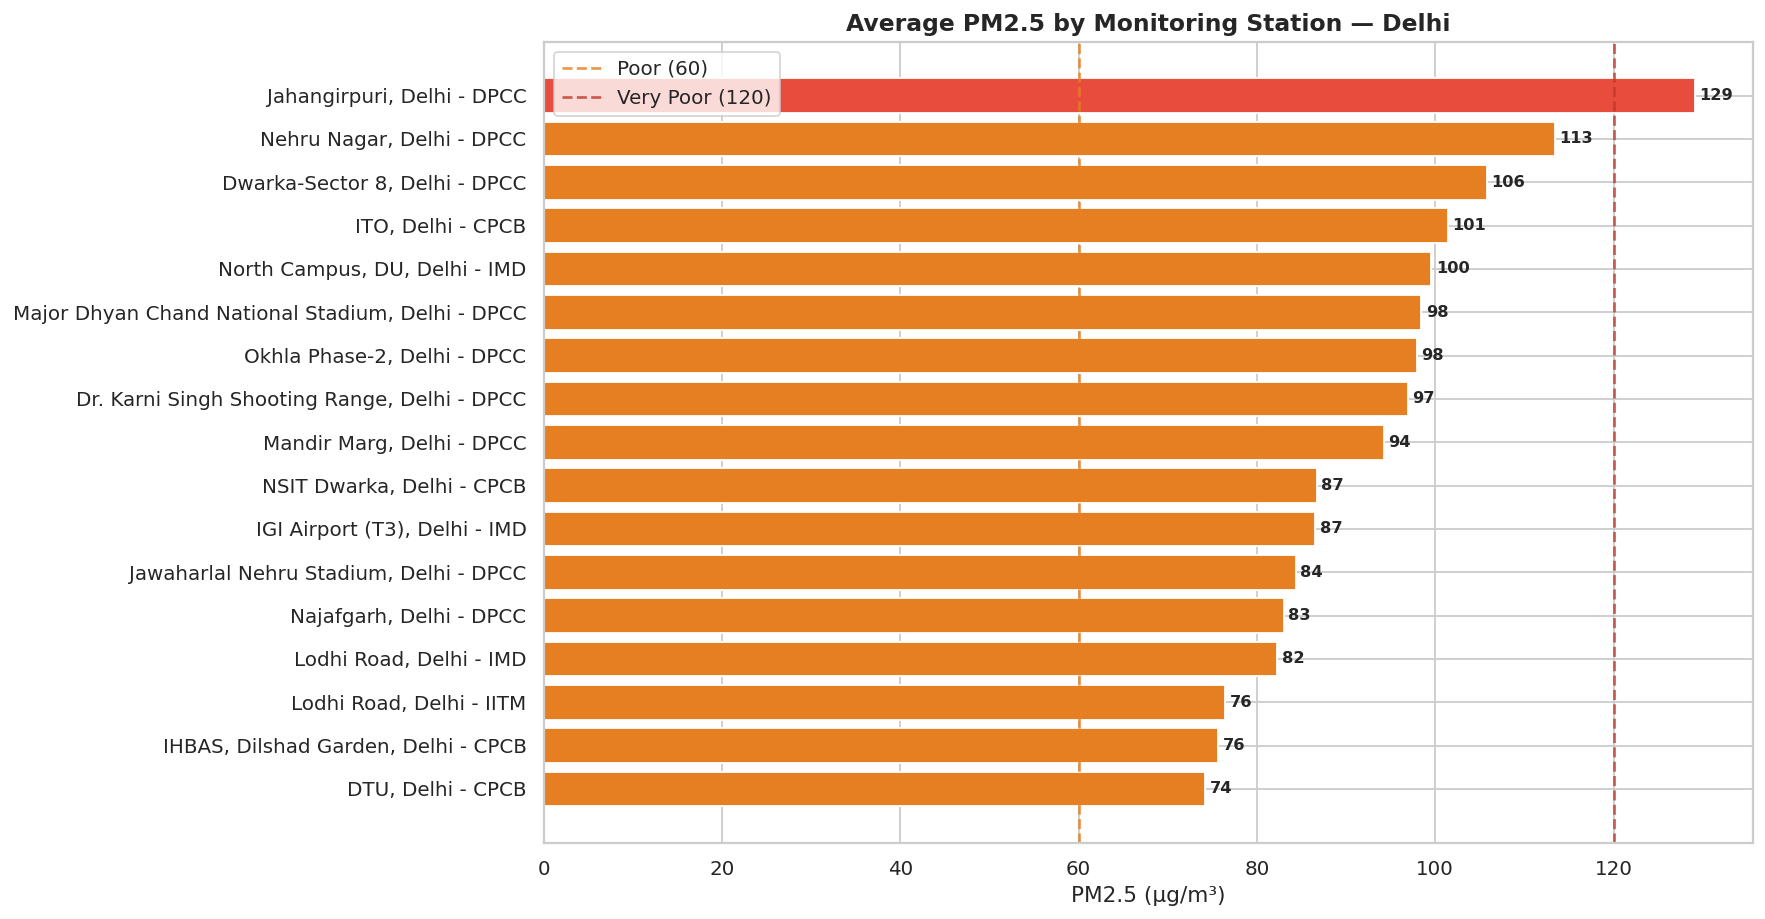

  ✓ Saved & displayed → ./output_plots/03_pm25_by_station.png

Plot 4: Hourly Pollution Pattern (Diurnal Cycle)


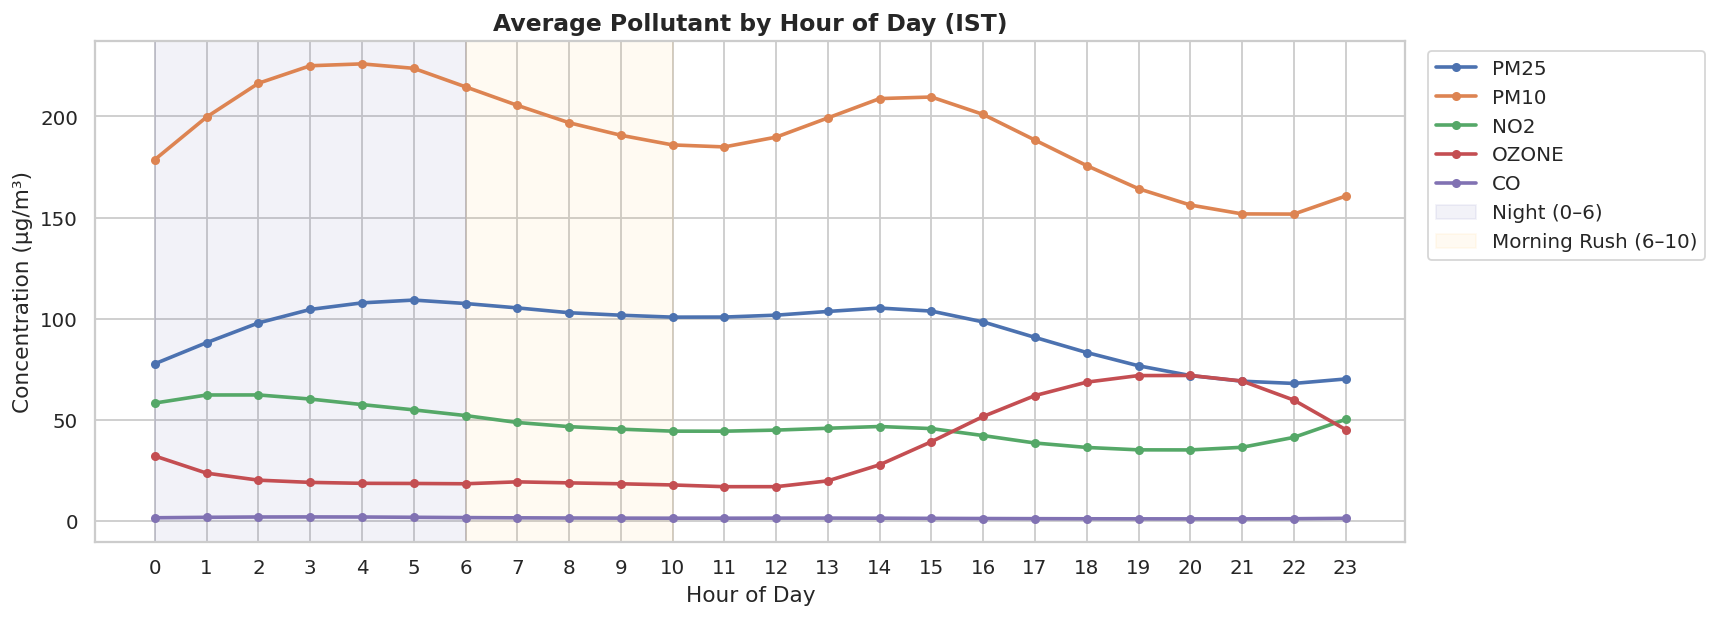

  ✓ Saved & displayed → ./output_plots/04_hourly_pattern.png

Plot 5: PM2.5 by Season


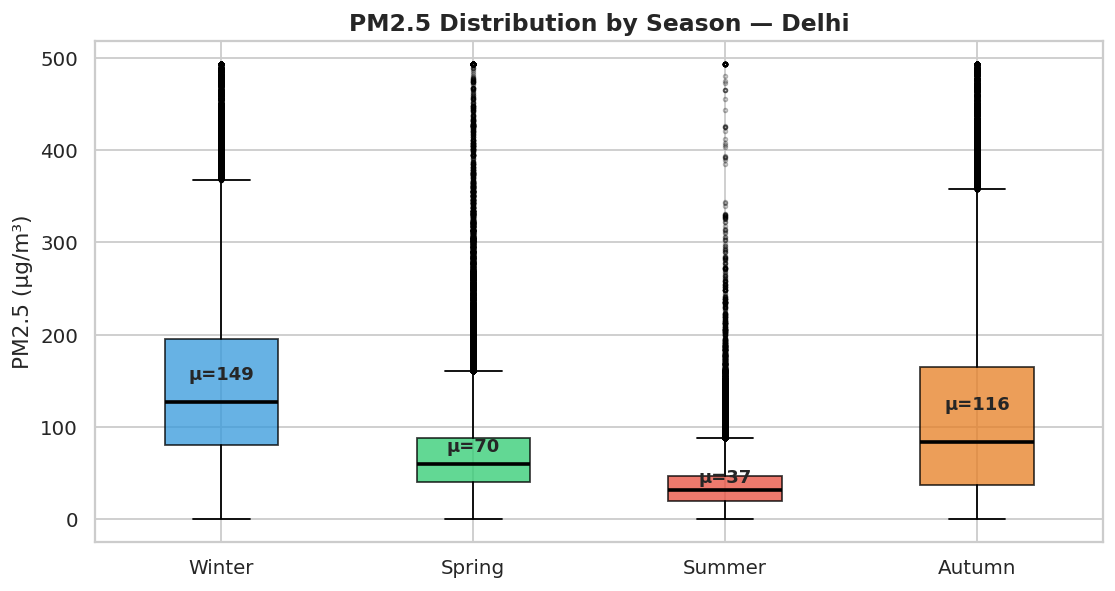

  ✓ Saved & displayed → ./output_plots/05_seasonal_boxplot.png

Plot 6: Weather vs Pollutant Correlation Heatmap

Plot 7: AQI Category Distribution


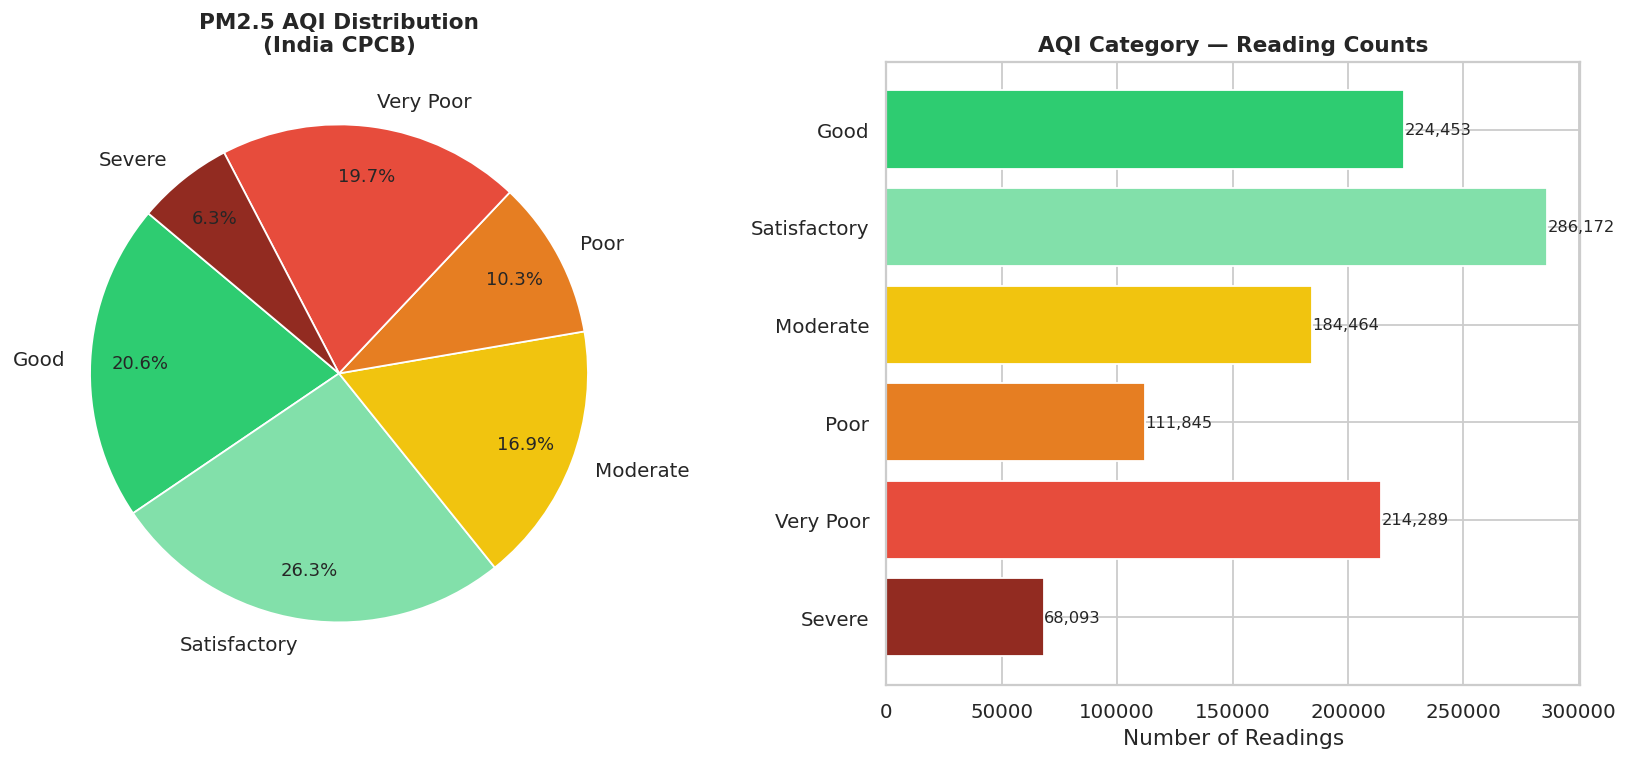

  ✓ Saved & displayed → ./output_plots/07_aqi_distribution.png

Plot 8: 2024 vs 2025 PM2.5 Comparison


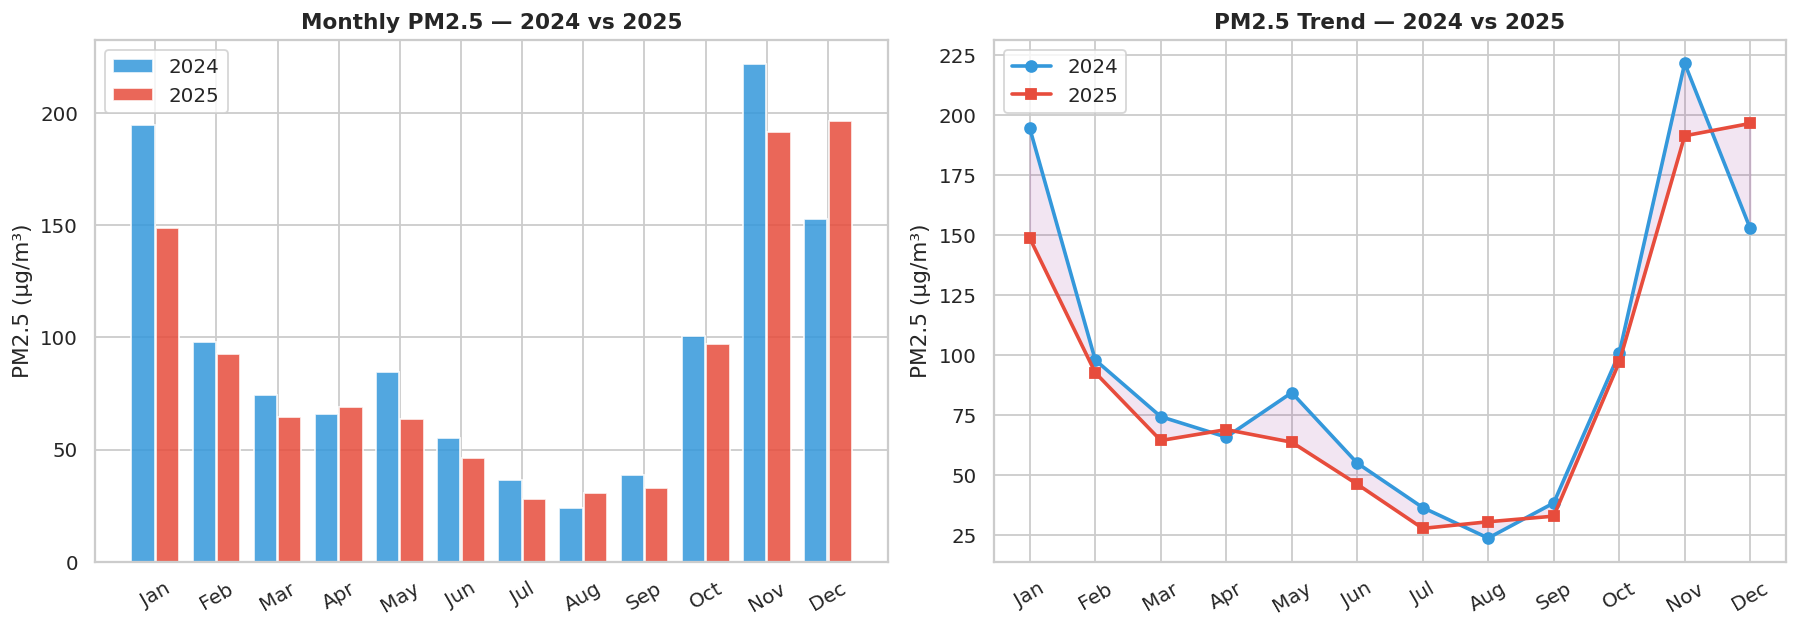

  ✓ Saved & displayed → ./output_plots/08_year_over_year.png

Plot 9: All Stations × All Pollutants Heatmap


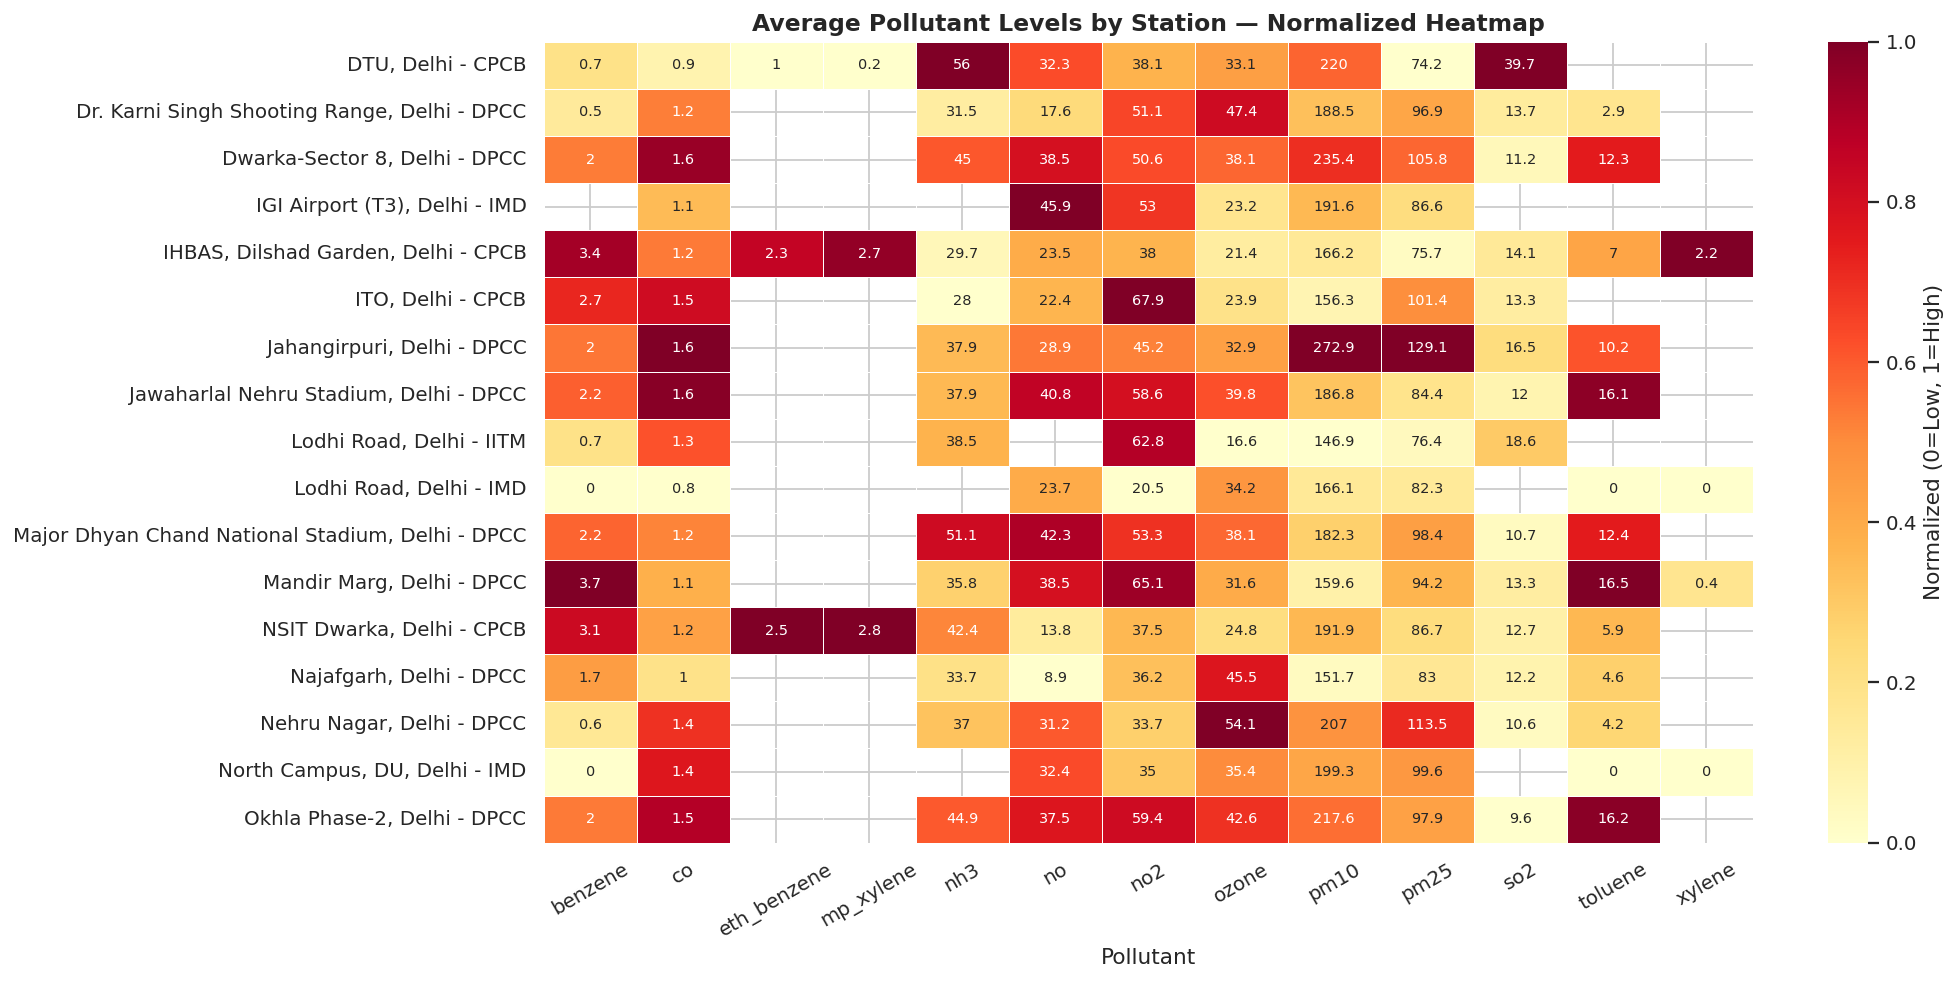

  ✓ Saved & displayed → ./output_plots/09_station_pollutant_heatmap.png

SUMMARY STATISTICS

--- PM2.5 by Season (mean) ---
season
Winter    148.7
Autumn    115.9
Spring     70.4
Summer     36.8

--- All Pollutant Means ---
pollutant
pm10           191.85
pm25            93.54
no2             47.24
nh3             39.35
ozone           35.20
no              29.87
so2             14.91
toluene          8.30
mp_xylene        2.12
eth_benzene      2.07
benzene          1.74
co               1.27
xylene           0.90

--- AQI Category Distribution ---
aqi_category
Satisfactory    286172
Good            224453
Very Poor       214289
Moderate        184464
Poor            111845
Severe           68093

--- Top 3 Most Polluted Stations (PM2.5) ---
station_name
Jahangirpuri, Delhi - DPCC       129.1
Nehru Nagar, Delhi - DPCC        113.5
Dwarka-Sector 8, Delhi - DPCC    105.8

Saving cleaned datasets...
✓ cleaned_long.csv saved
✓ cleaned_wide.csv saved
✓ summary_stats.csv saved

MILESTONE 3 C

In [8]:
"""
==============================================================
MILESTONE 3 — Data Cleaning, Transformation & Visualization
Team 7 — Delhi Air Quality & Weather Dataset (2024–2025)
==============================================================
"""

# ── CELL 1: Install & Import ──────────────────────────────────
import zipfile, io, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

os.makedirs("./output_plots", exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 5)})
print("✓ Libraries imported")


# ── CELL 2: Load All 219 CSV Files ───────────────────────────
ZIP_PATH = "./air_quality_csvs.zip"   # ← update path if needed

zf    = zipfile.ZipFile(ZIP_PATH)
files = sorted(zf.namelist())
print(f"Found {len(files)} CSV files in zip")

dfs = []
for i, fname in enumerate(files, 1):
    dfs.append(pd.read_csv(io.BytesIO(zf.read(fname)), parse_dates=["datetime"]))
    if i % 50 == 0 or i == len(files):
        print(f"  Loaded {i}/{len(files)} files...")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\n✓ Raw data shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(df_raw.head(3))


# ── CELL 3: Raw Data Inspection ───────────────────────────────
print("=" * 55)
print("RAW DATA INSPECTION")
print("=" * 55)

weather_cols = ["at_c","rh_percent","ws_m_s","wd_deg",
                "rf_mm","tot_rf_mm","sr_w_mt2","bp_mmhg","vws_m_s"]

print("\n--- Column Data Types ---")
print(df_raw.dtypes)

print("\n--- Missing Values (count and %) ---")
miss = pd.DataFrame({
    "count": df_raw.isnull().sum(),
    "%":     (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(miss[miss["count"] > 0])

print(f"\n--- Duplicate rows: {df_raw.duplicated().sum()} ---")

print("\n--- Redundant Columns Check ---")
print("'timestamp' duplicates 'datetime'?",
      (df_raw["timestamp"].str[:10] == df_raw["datetime"].dt.strftime("%Y-%m-%d")).all())
print("'station' duplicates 'station_name'?",
      (df_raw["station"] == df_raw["station_name"]).all())

print("\n--- Unique Stations ---")
print(df_raw[["station_id","station_name"]].drop_duplicates().sort_values("station_name").to_string(index=False))

print("\n--- Pollutant Value Stats ---")
print(df_raw.groupby("pollutant")["value"]
      .describe()[["count","mean","std","min","max"]].round(2).to_string())


# ── CELL 4: Data Cleaning ─────────────────────────────────────
print("=" * 55)
print("STEP 3: DATA CLEANING")
print("=" * 55)

df = df_raw.copy()

# 3.1 Drop redundant columns
drop_cols = ["timestamp", "station", "year", "month", "day", "hour"]
df.drop(columns=drop_cols, inplace=True)
print(f"3.1 ✓ Dropped redundant columns: {drop_cols}")

# 3.2 Convert UTC → IST
df["datetime"] = df["datetime"].dt.tz_convert("Asia/Kolkata")
print("3.2 ✓ Datetime converted: UTC → IST (Asia/Kolkata)")

# 3.3 Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"3.3 ✓ Removed {before - len(df)} duplicate rows")

# 3.4 Fill missing weather values (forward fill per station)
df.sort_values(["station_id","datetime"], inplace=True)
df.reset_index(drop=True, inplace=True)
print("\n3.4 Filling missing weather values (forward + backward fill per station):")
for col in weather_cols:
    before_n = df[col].isnull().sum()
    df[col] = df.groupby("station_id")[col].transform(lambda x: x.ffill().bfill())
    after_n  = df[col].isnull().sum()
    print(f"    {col:12s}: {before_n:,} → {after_n:,} nulls")

# 3.5 Cap outliers at 99.5th percentile per pollutant
print("\n3.5 Capping outliers at 99.5th percentile per pollutant:")
for p in df["pollutant"].unique():
    mask = df["pollutant"] == p
    cap  = df.loc[mask, "value"].quantile(0.995)
    n    = (df.loc[mask, "value"] > cap).sum()
    df.loc[mask & (df["value"] > cap), "value"] = cap
    if n > 0:
        print(f"    {p:15s}: {n} values capped at {cap:.2f}")

# 3.6 Remove negative sensor values
neg = (df["value"] < 0).sum()
df.loc[df["value"] < 0, "value"] = np.nan
print(f"\n3.6 ✓ Set {neg} negative values → NaN")

# 3.7 Standardize text
df["state"]        = df["state"].str.strip().str.title()
df["city"]         = df["city"].str.strip().str.title()
df["station_name"] = df["station_name"].str.strip()
df["pollutant"]    = df["pollutant"].str.strip().str.lower()
print("3.7 ✓ Standardized text columns")

print(f"\n✓ Cleaned shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


# ── CELL 5: Transformation ────────────────────────────────────
print("=" * 55)
print("STEP 4: TRANSFORMATION")
print("=" * 55)

# 4.1 Re-extract time features in IST
df["year"]    = df["datetime"].dt.year
df["month"]   = df["datetime"].dt.month
df["day"]     = df["datetime"].dt.day
df["hour"]    = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.day_name()
df["season"]  = df["month"].map({
    12:"Winter",1:"Winter",2:"Winter",
    3:"Spring",4:"Spring",5:"Spring",
    6:"Summer",7:"Summer",8:"Summer",
    9:"Autumn",10:"Autumn",11:"Autumn"
})
print("4.1 ✓ Added: year, month, day, hour, weekday, season")

# 4.2 AQI category (India CPCB PM2.5 standard)
def pm25_aqi(v):
    if pd.isna(v):  return "Unknown"
    if v <= 30:     return "Good"
    if v <= 60:     return "Satisfactory"
    if v <= 90:     return "Moderate"
    if v <= 120:    return "Poor"
    if v <= 250:    return "Very Poor"
    return "Severe"

pm25_mask = df["pollutant"] == "pm25"
df.loc[pm25_mask, "aqi_category"] = df.loc[pm25_mask, "value"].apply(pm25_aqi)
print("4.2 ✓ Added 'aqi_category' column (India CPCB PM2.5 standard)")

# 4.3 Wide format
print("4.3 Creating wide-format pivot table...")
df_wide = df.pivot_table(
    index   =["station_id","station_name","city","state","datetime",
               "year","month","day","hour","season","weekday",
               "at_c","rh_percent","ws_m_s","wd_deg",
               "rf_mm","tot_rf_mm","sr_w_mt2","bp_mmhg","vws_m_s"],
    columns ="pollutant",
    values  ="value",
    aggfunc ="mean"
).reset_index()
df_wide.columns.name = None
print(f"4.3 ✓ Wide format: {df_wide.shape[0]:,} rows × {df_wide.shape[1]} columns")
print("\n✓ All transformations complete!")


# ── CELL 6: VISUALIZATION HELPER ─────────────────────────────
def save_show(fig, name, title=""):
    path = f"./output_plots/{name}.png"
    fig.savefig(path, bbox_inches="tight", dpi=130)
    plt.show()
    print(f"  ✓ Saved & displayed → {path}")


# ── CELL 7: Plot 1 — Missing Values ──────────────────────────
print("\nPlot 1: Missing Values Heatmap (Before Cleaning)")
fig, ax = plt.subplots(figsize=(10, 5))
mp = df_raw[weather_cols].isnull().mean() * 100
colors = ["#e74c3c" if v > 50 else "#e67e22" if v > 20 else "#2ecc71"
          for v in mp.values]
bars = ax.barh(mp.index, mp.values, color=colors, edgecolor="white")
for bar, val in zip(bars, mp.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 100)
ax.set_xlabel("Missing Values (%)", fontsize=11)
ax.set_title("Missing Values per Weather Column — Before Cleaning", fontsize=13, fontweight="bold")
patches = [mpatches.Patch(color="#e74c3c", label=">50% (Critical)"),
           mpatches.Patch(color="#e67e22", label=">20% (High)"),
           mpatches.Patch(color="#2ecc71", label="<20% (Acceptable)")]
ax.legend(handles=patches, loc="lower right")
save_show(fig, "01_missing_values")


# ── CELL 8: Plot 2 — PM2.5 Monthly Trend ─────────────────────
print("\nPlot 2: PM2.5 Monthly Trend (2024–2025)")
pm25_mo = (df[df["pollutant"]=="pm25"]
           .groupby(["year","month"])["value"].mean().reset_index())
pm25_mo["period"] = (pm25_mo["year"].astype(str) + "-" +
                     pm25_mo["month"].astype(str).str.zfill(2))
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(pm25_mo["period"], pm25_mo["value"], alpha=0.15, color="#e74c3c")
ax.plot(pm25_mo["period"], pm25_mo["value"],
        marker="o", color="#e74c3c", lw=2.5, ms=6, label="Monthly Avg PM2.5")
ax.axhline(60,  color="#e67e22", ls="--", lw=1.5, alpha=0.8, label="Poor threshold (60)")
ax.axhline(120, color="#c0392b", ls="--", lw=1.5, alpha=0.8, label="Very Poor threshold (120)")
ax.set_title("Monthly Average PM2.5 — Delhi (2024–2025)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(); plt.xticks(rotation=45, ha="right", fontsize=8)
save_show(fig, "02_pm25_monthly_trend")


# ── CELL 9: Plot 3 — PM2.5 by Station ────────────────────────
print("\nPlot 3: Average PM2.5 by Monitoring Station")
pm25_st = (df[df["pollutant"]=="pm25"]
           .groupby("station_name")["value"].mean().sort_values())
c3 = ["#e74c3c" if v>120 else "#e67e22" if v>60 else "#2ecc71"
      for v in pm25_st.values]
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(pm25_st.index, pm25_st.values, color=c3, edgecolor="white")
for bar, val in zip(bars, pm25_st.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}", va="center", fontsize=9, fontweight="bold")
ax.axvline(60,  color="#e67e22", ls="--", lw=1.5, alpha=0.8, label="Poor (60)")
ax.axvline(120, color="#c0392b", ls="--", lw=1.5, alpha=0.8, label="Very Poor (120)")
ax.set_title("Average PM2.5 by Monitoring Station — Delhi", fontsize=13, fontweight="bold")
ax.set_xlabel("PM2.5 (µg/m³)"); ax.legend()
save_show(fig, "03_pm25_by_station")


# ── CELL 10: Plot 4 — Hourly Diurnal Pattern ─────────────────
print("\nPlot 4: Hourly Pollution Pattern (Diurnal Cycle)")
top_p = ["pm25","pm10","no2","ozone","co"]
hrly  = (df[df["pollutant"].isin(top_p)]
         .groupby(["hour","pollutant"])["value"].mean().reset_index())
fig, ax = plt.subplots(figsize=(13, 5))
for p in top_p:
    d = hrly[hrly["pollutant"]==p]
    ax.plot(d["hour"], d["value"], marker="o", ms=4, lw=2, label=p.upper())
ax.axvspan(0, 6,  alpha=0.05, color="navy",  label="Night (0–6)")
ax.axvspan(6, 10, alpha=0.05, color="orange", label="Morning Rush (6–10)")
ax.set_title("Average Pollutant by Hour of Day (IST)", fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of Day"); ax.set_ylabel("Concentration (µg/m³)")
ax.set_xticks(range(24)); ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
save_show(fig, "04_hourly_pattern")


# ── CELL 11: Plot 5 — Seasonal Boxplot ───────────────────────
print("\nPlot 5: PM2.5 by Season")
season_order = ["Winter","Spring","Summer","Autumn"]
pm_df = df[df["pollutant"]=="pm25"]
fig, ax = plt.subplots(figsize=(10, 5))
ds = [pm_df[pm_df["season"]==s]["value"].dropna() for s in season_order]
bp = ax.boxplot(ds, labels=season_order, patch_artist=True,
                medianprops=dict(color="black", lw=2),
                flierprops=dict(marker="o", ms=2, alpha=0.3))
for patch, c in zip(bp["boxes"], ["#3498db","#2ecc71","#e74c3c","#e67e22"]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
season_means = [pm_df[pm_df["season"]==s]["value"].mean() for s in season_order]
for i, mean in enumerate(season_means):
    ax.text(i+1, mean+3, f"μ={mean:.0f}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("PM2.5 Distribution by Season — Delhi", fontsize=13, fontweight="bold")
ax.set_ylabel("PM2.5 (µg/m³)")
save_show(fig, "05_seasonal_boxplot")


# ── CELL 12: Plot 6 — Correlation Heatmap ────────────────────
print("\nPlot 6: Weather vs Pollutant Correlation Heatmap")

# Define columns to check
wc = ["at_c", "rh_percent", "ws_m_s", "sr_w_mt2", "bp_mmhg"]
pc = [c for c in ["pm25", "pm10", "no2", "ozone", "co", "so2", "no"] if c in df_wide.columns]

# FIX: Ensure all targeted columns exist in df_wide and force them to numeric type
valid_cols = [col for col in (wc + pc) if col in df_wide.columns]
df_numeric_corr = df_wide[valid_cols].apply(pd.to_numeric, errors='coerce')

# Filter the defined weather and pollutant columns that successfully converted
available_wc = [col for col in wc if col in df_numeric_corr.columns]
available_pc = [col for col in pc if col in df_numeric_corr.columns]

# Compute the correlation matrix sliced by Weather vs Pollutants
corr = df_numeric_corr.corr().loc[available_wc, available_pc]

# If the matrix is empty or all NaN, print a warning; otherwise, plot
if corr.isnull().all().all():
    print("Warning: Not enough numeric variance or data to compute correlations for Plot 6.")
else:
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                ax=ax, linewidths=0.5, annot_kws={"size": 10},
                cbar_kws={"label": "Pearson r"})
    ax.set_title("Weather vs Pollutant Correlation Heatmap", fontsize=13, fontweight="bold")
    ax.set_ylabel("Weather Variables")
    ax.set_xlabel("Pollutants")
    save_show(fig, "06_correlation_heatmap")


# ── CELL 13: Plot 7 — AQI Pie Chart ──────────────────────────
print("\nPlot 7: AQI Category Distribution")
aqic = df.loc[pm25_mask, "aqi_category"].value_counts()
order = ["Good","Satisfactory","Moderate","Poor","Very Poor","Severe"]
aqic  = aqic.reindex([o for o in order if o in aqic.index])
clrs  = ["#2ecc71","#82e0aa","#f1c40f","#e67e22","#e74c3c","#922b21"]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
wedges, texts, autotexts = axes[0].pie(
    aqic.values, labels=aqic.index, colors=clrs[:len(aqic)],
    autopct="%1.1f%%", startangle=140, pctdistance=0.80)
for t in autotexts: t.set_fontsize(10)
axes[0].set_title("PM2.5 AQI Distribution\n(India CPCB)", fontsize=12, fontweight="bold")
axes[1].barh(aqic.index[::-1], aqic.values[::-1],
             color=clrs[:len(aqic)][::-1], edgecolor="white")
axes[1].set_xlabel("Number of Readings")
axes[1].set_title("AQI Category — Reading Counts", fontsize=12, fontweight="bold")
for i, val in enumerate(aqic.values[::-1]):
    axes[1].text(val + 200, i, f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
save_show(fig, "07_aqi_distribution")


# ── CELL 14: Plot 8 — Year over Year ─────────────────────────
print("\nPlot 8: 2024 vs 2025 PM2.5 Comparison")
yoy = df[df["pollutant"]=="pm25"].groupby(["year","month"])["value"].mean().reset_index()
y24 = yoy[yoy["year"]==2024].set_index("month")["value"].reindex(range(1,13), fill_value=np.nan)
y25 = yoy[yoy["year"]==2025].set_index("month")["value"].reindex(range(1,13), fill_value=np.nan)
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
x = np.arange(12)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar chart
axes[0].bar(x-0.2, y24.values, 0.38, label="2024", color="#3498db", alpha=0.85)
axes[0].bar(x+0.2, y25.values, 0.38, label="2025", color="#e74c3c", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(months, rotation=30)
axes[0].set_title("Monthly PM2.5 — 2024 vs 2025", fontsize=12, fontweight="bold")
axes[0].set_ylabel("PM2.5 (µg/m³)"); axes[0].legend()
# Line chart
axes[1].plot(months, y24.values, marker="o", color="#3498db", lw=2, label="2024")
axes[1].plot(months, y25.values, marker="s", color="#e74c3c", lw=2, label="2025")
axes[1].fill_between(months, y24.values, y25.values, alpha=0.1, color="purple")
axes[1].set_title("PM2.5 Trend — 2024 vs 2025", fontsize=12, fontweight="bold")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].legend(); plt.xticks(rotation=30)
plt.tight_layout()
save_show(fig, "08_year_over_year")


# ── CELL 15: Plot 9 — Station × Pollutant Heatmap ────────────
print("\nPlot 9: All Stations × All Pollutants Heatmap")
pivot = df.groupby(["station_name","pollutant"])["value"].mean().unstack("pollutant")
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())
fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(pivot_norm, annot=pivot.round(1), fmt="g",
            cmap="YlOrRd", ax=ax, linewidths=0.4,
            cbar_kws={"label": "Normalized (0=Low, 1=High)"},
            annot_kws={"size": 8})
ax.set_title("Average Pollutant Levels by Station — Normalized Heatmap",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Pollutant"); ax.set_ylabel("")
plt.xticks(rotation=30); plt.yticks(rotation=0)
save_show(fig, "09_station_pollutant_heatmap")


# ── CELL 16: Summary Stats + Save Cleaned Data ───────────────
print("\n" + "="*55)
print("SUMMARY STATISTICS")
print("="*55)

print("\n--- PM2.5 by Season (mean) ---")
print(df[df["pollutant"]=="pm25"].groupby("season")["value"]
      .mean().round(1).sort_values(ascending=False).to_string())

print("\n--- All Pollutant Means ---")
print(df.groupby("pollutant")["value"].mean().round(2)
      .sort_values(ascending=False).to_string())

print("\n--- AQI Category Distribution ---")
print(df.loc[pm25_mask,"aqi_category"].value_counts().to_string())

print("\n--- Top 3 Most Polluted Stations (PM2.5) ---")
top3 = (df[df["pollutant"]=="pm25"].groupby("station_name")["value"]
        .mean().sort_values(ascending=False).head(3))
print(top3.round(1).to_string())

print("\nSaving cleaned datasets...")
df.to_csv("./cleaned_long.csv", index=False)
df_wide.to_csv("./cleaned_wide.csv", index=False)
df.groupby("pollutant")["value"].describe().round(2).to_csv("./summary_stats.csv")
print("✓ cleaned_long.csv saved")
print("✓ cleaned_wide.csv saved")
print("✓ summary_stats.csv saved")

print("\n" + "="*55)
print("MILESTONE 3 COMPLETE!")
print(f"Raw rows     : {len(df_raw):,}")
print(f"Cleaned rows : {len(df):,}")
print(f"Columns      : {len(df.columns)}")
print(f"Plots saved  : ./output_plots/  (9 plots)")
print(f"Data saved   : cleaned_long.csv, cleaned_wide.csv")
print("="*55)